In [9]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import plot_tree
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
import numpy as np
from mlxtend.plotting import plot_decision_regions
import matplotlib.pyplot as plt

In [10]:
# X, y = fetch_openml("iris", version=1, return_X_y=True, as_frame=False) # as_frame=False returns numpy arrays instead of pandas dataframes

data = load_iris(return_X_y=False)  # Load the Iris dataset
X, y = data.data[:, [2,3]], data.target
print(X.shape, y.shape)
print(data.feature_names)
print(data.target_names)
print(y)

(150, 2) (150,)
['sepal length (cm)', 'sepal width (cm)', 'petal length (cm)', 'petal width (cm)']
['setosa' 'versicolor' 'virginica']
[0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 2 2 2 2 2 2 2 2 2 2 2
 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2
 2 2]


In [11]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print(X_train.shape, y_train.shape)
print(X_test.shape, y_test.shape)

(120, 2) (120,)
(30, 2) (30,)


Accuracy: 1.0000


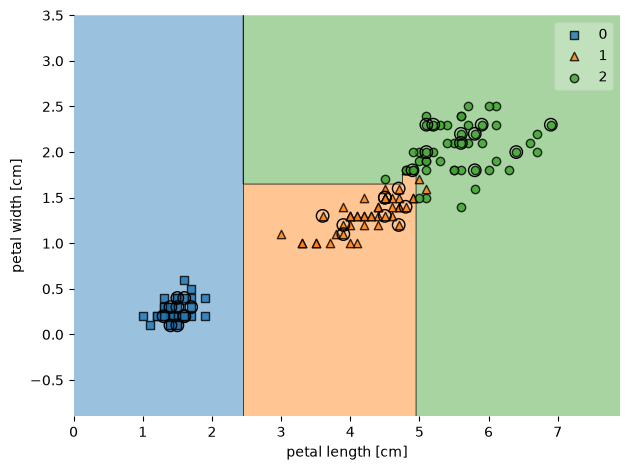

In [4]:
tree = DecisionTreeClassifier(criterion='entropy', max_depth=4, random_state=42)
clf = tree.fit(X_train, y_train)
accuracy = clf.score(X_test, y_test)
print(f"Accuracy: {accuracy:.4f}")
X_combined = np.vstack((X_train, X_test))
y_combined = np.hstack((y_train, y_test))
plot_decision_regions(X_combined, y_combined, clf=tree, X_highlight=X_test)
plt.xlabel('petal length [cm]')
plt.ylabel('petal width [cm]')
plt.tight_layout()
plt.show()

Random Forest Accuracy: 1.0000


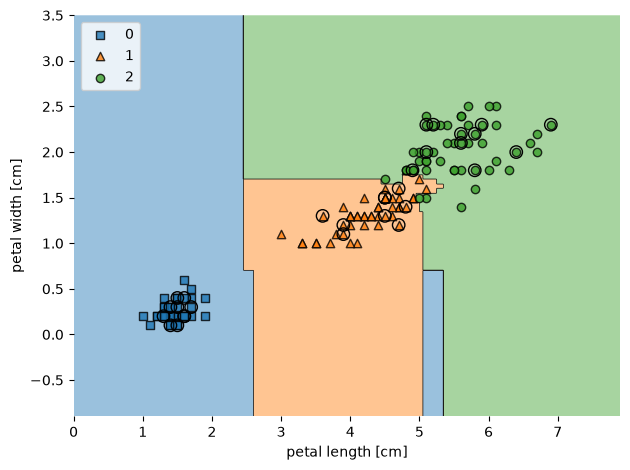

In [ ]:
# n_jobs: The number of jobs to run in parallel.
# n_estimators: The number of trees in the forest
forest = RandomForestClassifier(n_estimators=25,
                                criterion='gini', 
                                random_state=42, 
                                n_jobs=2) 
forest_cls = forest.fit(X_train, y_train)
acc = forest.score(X_test, y_test)
print(f"Random Forest Accuracy: {acc:.4f}")
X_combined = np.vstack((X_train, X_test))
y_combined = np.hstack((y_train, y_test))
plot_decision_regions(X_combined, y_combined, clf=forest, X_highlight=X_test)
plt.xlabel('petal length [cm]')
plt.ylabel('petal width [cm]')
plt.legend(loc='upper left')
plt.tight_layout()
plt.show()

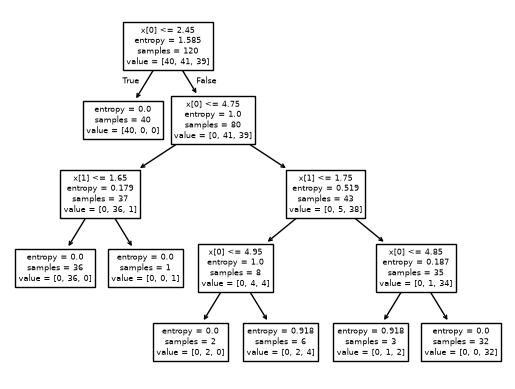

In [5]:
plot_tree(clf)
plt.show()

In [8]:
from pydotplus import graph_from_dot_data
from sklearn.tree import export_graphviz
dot_data = export_graphviz(clf, out_file=None, feature_names=data.feature_names[2:], class_names=data.target_names, filled=True, rounded=True, special_characters=True)

graph = graph_from_dot_data(dot_data)
graph.write_png("iris_tree.png")

True